# AirQualityHealth — Continuation Notebook
Extends your existing work with feature engineering, modeling, and plots.
_Generated: 2025-11-08 22:00_

In [3]:
# Setup
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# If CSV is in same folder as this notebook:
DATA_PATH = Path('air_quality_health_dataset.csv')
assert DATA_PATH.exists(), 'Dataset not found. Put the CSV next to the notebook.'

# Create output folders locally
BASE_OUT = Path('Team4_Deliverables')
FIG_OUT = BASE_OUT / 'figs'
BASE_OUT.mkdir(exist_ok=True)
FIG_OUT.mkdir(exist_ok=True)

# Feedback: remove future years beyond ~2040 (or 2035 if you prefer)
MAX_YEAR = 2040  # change to 2035 if your instructor wants stricter cutoff
print(f'Using only data with year <= {MAX_YEAR}')

DATA_PATH

Using only data with year <= 2040


WindowsPath('air_quality_health_dataset.csv')

In [4]:
# Load & clean (with year cutoff from feedback)
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(['city','date']).dropna(subset=['date']).reset_index(drop=True)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Apply year filter per feedback
df = df[df['year'] <= MAX_YEAR].copy()
df.reset_index(drop=True, inplace=True)

print('Year range after filtering:', int(df['year'].min()), '→', int(df['year'].max()))
print('Rows after filtering:', len(df))
df.head()

Year range after filtering: 2020 → 2040
Rows after filtering: 7671


,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity,year,month
0,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545,2020,1
1,Beijing,2020-01-10,279,27.1,101.0,47.8,42.2,-2.1,24,8,Urban,179,2020,1
2,Beijing,2020-01-11,484,56.6,46.3,33.2,27.3,27.9,62,9,Urban,600,2020,1
3,Beijing,2020-01-15,475,45.0,47.6,38.5,54.6,10.4,76,6,Urban,1461,2020,1
4,Beijing,2020-01-22,164,31.1,66.1,20.2,31.9,5.1,69,8,Suburban,1500,2020,1


## Basic EDA

In [5]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
city,7671,8,Delhi,2351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,7671,NaN,NaN,NaN,2030-07-02 00:00:00,2020-01-01 00:00:00,2025-04-01 12:00:00,2030-07-02 00:00:00,2035-10-01 12:00:00,2040-12-31 00:00:00,NaN
aqi,7671.0,NaN,NaN,NaN,250.050841,0.0,124.0,251.0,374.0,499.0,144.842702
pm2_5,7671.0,NaN,NaN,NaN,35.17063,0.1,24.95,35.2,45.25,103.8,14.818539
pm10,7671.0,NaN,NaN,NaN,50.200482,0.0,36.55,50.1,63.8,124.5,19.847156
no2,7671.0,NaN,NaN,NaN,29.846669,0.0,23.2,29.8,36.6,65.2,9.857735
o3,7671.0,NaN,NaN,NaN,40.048651,0.4,32.0,40.0,48.2,93.5,12.064927
temperature,7671.0,NaN,NaN,NaN,17.360448,-5.0,6.0,17.3,28.7,40.0,13.000535
humidity,7671.0,NaN,NaN,NaN,56.791944,20.0,38.0,57.0,75.0,94.0,21.675417
hospital_admissions,7671.0,NaN,NaN,NaN,8.094251,0.0,6.0,8.0,11.0,22.0,3.656233


In [6]:
# Missingness summary
missing = df.isna().mean().sort_values(ascending=False)
missing.to_frame('missing_frac')

,missing_frac
city,0.0
date,0.0
aqi,0.0
pm2_5,0.0
pm10,0.0
no2,0.0
o3,0.0
temperature,0.0
humidity,0.0
hospital_admissions,0.0


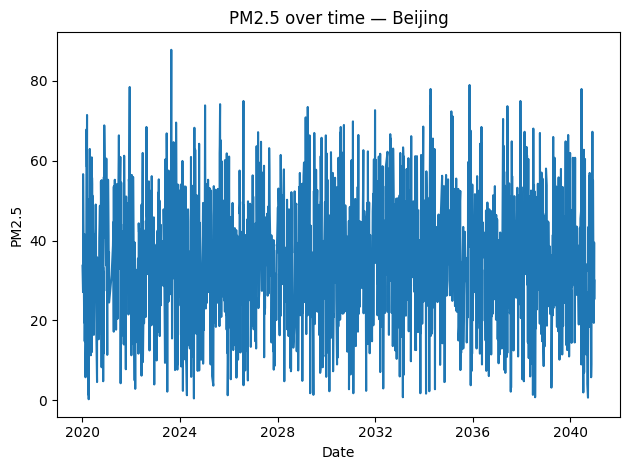

In [7]:
# Simple time series plot for one city (change as needed)
city0 = df['city'].iloc[0]
sub = df[df['city']==city0]
plt.figure()
plt.plot(sub['date'], sub['pm2_5'])
plt.title(f'PM2.5 over time — {city0}')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.savefig(FIG_OUT / 'pm25_timeseries.png')
plt.show()

## Feature Engineering
- Aggregate to **monthly** by city.
- Create **lag-1 month** features for pollutants.
- Rolling 3-month means.

In [8]:
pollutant_cols = ['aqi','pm2_5','pm10','no2','o3','temperature','humidity']
target_col = 'hospital_admissions'
cap_col = 'hospital_capacity'

monthly = (
    df.groupby(['city','year','month'], as_index=False)
      .agg({**{c:'mean' for c in pollutant_cols}, target_col:'sum', cap_col:'mean'})
)
monthly['date_key'] = pd.to_datetime(dict(year=monthly['year'], month=monthly['month'], day=1))

# Lags and rolling means per city
monthly = monthly.sort_values(['city','date_key']).reset_index(drop=True)
for c in pollutant_cols:
    monthly[f'{c}_lag1'] = monthly.groupby('city')[c].shift(1)
    monthly[f'{c}_roll3'] = monthly.groupby('city')[c].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)

# Target next-month to avoid leakage (optional)
monthly['target_next'] = monthly.groupby('city')[target_col].shift(-1)
monthly.dropna(subset=['target_next'], inplace=True)
monthly.head()

,city,year,month,aqi,pm2_5,pm10,no2,o3,temperature,humidity,...,pm10_roll3,no2_lag1,no2_roll3,o3_lag1,o3_roll3,temperature_lag1,temperature_roll3,humidity_lag1,humidity_roll3,target_next
0,Beijing,2020,1,320.166667,35.500000,54.300000,33.533333,37.933333,8.150000,50.166667,...,54.300000,NaN,33.533333,NaN,37.933333,NaN,8.150000,NaN,50.166667,69.0
1,Beijing,2020,2,286.000000,21.525000,50.487500,27.400000,45.062500,17.837500,52.125000,...,52.393750,33.533333,30.466667,37.933333,41.497917,8.150000,12.993750,50.166667,51.145833,51.0
2,Beijing,2020,3,229.571429,42.842857,62.957143,24.628571,41.257143,21.385714,69.714286,...,55.914881,27.400000,28.520635,45.062500,41.417659,17.837500,15.791071,52.125000,57.335317,62.0
3,Beijing,2020,4,196.250000,30.412500,49.900000,30.100000,35.550000,24.637500,52.625000,...,54.448214,24.628571,27.376190,41.257143,40.623214,21.385714,21.286905,69.714286,58.154762,89.0
4,Beijing,2020,5,271.000000,38.381818,59.727273,31.481818,40.127273,16.654545,56.000000,...,57.528139,30.100000,28.736797,35.550000,38.978139,24.637500,20.892587,52.625000,59.446429,27.0


## Train / Test split (temporal)

In [9]:
monthly = monthly.sort_values('date_key')
cutoff = int(len(monthly)*0.8)
train = monthly.iloc[:cutoff].copy()
test = monthly.iloc[cutoff:].copy()
train.shape, test.shape

((1367, 28), (342, 28))

## Regression: predict next-month admissions (`target_next`)

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# ---- features ----
feature_cols = []
for c in pollutant_cols:
    feature_cols += [c, f'{c}_lag1', f'{c}_roll3']
feature_cols += ['hospital_capacity']

# forward/backward fill (no deprecation warnings)
X_train = train[feature_cols].ffill().bfill()
y_train = train['target_next']
X_test  = test[feature_cols].ffill().bfill()
y_test  = test['target_next']

# numeric columns and preprocessor
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
pre = ColumnTransformer([('num', StandardScaler(), num_cols)], remainder='drop')

# models (faster RF)
ridge = Pipeline([('pre', pre), ('mdl', Ridge(alpha=1.0))])
rf = Pipeline([('pre', pre), ('mdl', RandomForestRegressor(
    n_estimators=100,     # fewer trees -> faster
    max_depth=10,        # cap depth -> faster/stable
    n_jobs=-1,           # use all CPU cores
    random_state=42
))])

models = {'ridge': ridge, 'rf': rf}
reg_results = {}
preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    preds[name] = p

    mae = mean_absolute_error(y_test, p)
    mse = mean_squared_error(y_test, p)       # no 'squared' kwarg on older sklearn
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, p)

    reg_results[name] = {'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2)}

reg_results


{'ridge': {'MAE': 22.123700941477804,
  'RMSE': 26.78013228708427,
  'R2': 0.004954539251055712},
 'rf': {'MAE': 17.77129375313982,
  'RMSE': 21.99236216985461,
  'R2': 0.3289401667740163}}

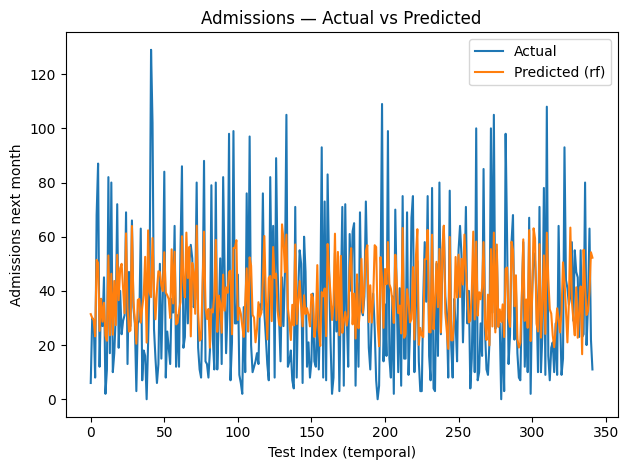

In [11]:
# Plot predictions vs actual for best model
best = max(reg_results.items(), key=lambda kv: kv[1]['R2'])[0]
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(preds[best], label=f'Predicted ({best})')
plt.title('Admissions — Actual vs Predicted')
plt.xlabel('Test Index (temporal)')
plt.ylabel('Admissions next month')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_OUT / 'regression_pred_vs_actual.png')
plt.show()

## Classification: flag high-risk months
Label = 1 if next-month admissions ≥ 80th percentile of training set.

In [12]:
thr = y_train.quantile(0.80)
y_train_cls = (y_train >= thr).astype(int)
y_test_cls = (y_test >= thr).astype(int)

clf = Pipeline([('pre', pre), ('mdl', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42))])
clf.fit(X_train, y_train_cls)
probs = clf.predict_proba(X_test)[:,1]
roc = roc_auc_score(y_test_cls, probs) if y_test_cls.nunique()>1 else np.nan
pr = average_precision_score(y_test_cls, probs) if y_test_cls.nunique()>1 else np.nan
pred_cls = (probs >= 0.5).astype(int)
cm = confusion_matrix(y_test_cls, pred_cls)
{'ROC_AUC': float(roc) if roc==roc else None, 'PR_AUC': float(pr) if pr==pr else None, 'ConfusionMatrix': cm.tolist()}

{'ROC_AUC': 0.8082225237449118,
 'PR_AUC': 0.5058685763844484,
 'ConfusionMatrix': [[256, 19], [43, 24]]}

## Permutation Importance (on RandomForest regressor)

In [13]:
rf_model = rf.named_steps['mdl']
rf.fit(X_train, y_train)
result = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42)
imp = pd.Series(result.importances_mean, index=num_cols).sort_values(ascending=False)
imp.head(15)

aqi_lag1             0.047423
pm10                 0.029588
humidity_roll3       0.027090
aqi_roll3            0.026702
temperature_lag1     0.023389
no2_roll3            0.021757
temperature_roll3    0.021131
o3_roll3             0.018940
pm10_roll3           0.014608
temperature          0.013982
hospital_capacity    0.013020
o3                   0.012722
o3_lag1              0.012608
pm10_lag1            0.012215
no2_lag1             0.010785
dtype: float64

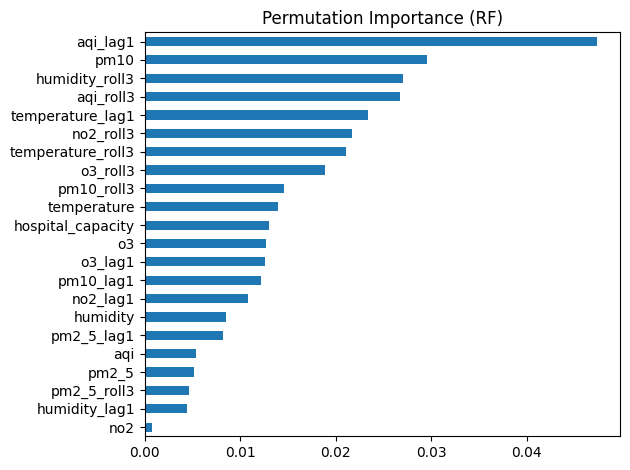

In [14]:
plt.figure()
imp.sort_values().plot(kind='barh')
plt.title('Permutation Importance (RF)')
plt.tight_layout()
plt.savefig(FIG_OUT / 'rf_permutation_importance.png')
plt.show()

## Export predictions

In [15]:
export = test[['city','year','month','date_key','target_next']].copy()
export['pred_regression'] = preds[best]
export['risk_prob'] = probs
export.to_csv(BASE_OUT / 'predictions.csv', index=False)
export.head()

,city,year,month,date_key,target_next,pred_regression,risk_prob
359,Cairo,2036,10,2036-10-01,6.0,31.428631,0.1325
1072,Los Angeles,2036,10,2036-10-01,30.0,30.023139,0.0700
840,London,2036,11,2036-11-01,29.0,29.219561,0.0375
1675,Tokyo,2036,11,2036-11-01,8.0,23.225475,0.0550
202,Beijing,2036,11,2036-11-01,68.0,51.473576,0.4075


All outputs saved to `/mnt/data/Team4_Deliverables`.

In [16]:
# --- A) Over-/Under-dispersion diagnostics (daily + monthly) ---
import pandas as pd, numpy as np

# Daily dispersion by city
disp_daily = (df.groupby('city')['hospital_admissions']
                .agg(['mean','var'])
                .assign(var_to_mean=lambda d: (d['var']/d['mean']).round(3)))
print("Daily dispersion (var/mean >> 1 => over-dispersion → NegBin often better):")
display(disp_daily)

# Monthly rollup (non-destructive)
_df_mA = df.copy()
_df_mA['date_key'] = pd.to_datetime(_df_mA['date'].dt.to_period('M').astype(str))
mA = (_df_mA.groupby(['city','date_key'], as_index=False)
      .agg({'hospital_admissions':'mean'})
      .rename(columns={'hospital_admissions':'target_month'}))
disp_monthly = (mA.groupby('city')['target_month']
                  .agg(['mean','var'])
                  .assign(var_to_mean=lambda d: (d['var']/d['mean']).round(3)))
print("Monthly dispersion:")
display(disp_monthly)


Daily dispersion (var/mean >> 1 => over-dispersion → NegBin often better):


,mean,var,var_to_mean
city,,,
Beijing,8.170324,13.130410,1.607
Cairo,8.506977,14.148316,1.663
Delhi,8.056572,13.627862,1.692
London,8.181373,13.863941,1.695
Los Angeles,7.951252,13.257515,1.667
Mexico City,8.080139,13.200198,1.634
São Paulo,7.848485,13.531781,1.724
Tokyo,8.027613,12.643505,1.575


Monthly dispersion:


,mean,var,var_to_mean
city,,,
Beijing,8.183699,2.251568,0.275
Cairo,8.720690,11.477868,1.316
Delhi,8.038403,1.785131,0.222
London,8.289948,8.701809,1.050
Los Angeles,7.863492,6.150211,0.782
Mexico City,8.003489,3.389097,0.423
São Paulo,7.911846,13.380937,1.691
Tokyo,7.913569,6.114543,0.773


In [17]:
# --- B) Monthly supervised table (predict next-month admissions; non-destructive) ---
import pandas as pd

_dfmB = df.copy()
_dfmB['date_key'] = pd.to_datetime(_dfmB['date'].dt.to_period('M').astype(str))

agg_num = {
    'aqi':'mean','pm2_5':'mean','pm10':'mean','no2':'mean','o3':'mean',
    'temperature':'mean','humidity':'mean','hospital_capacity':'mean',
    'hospital_admissions':'mean'
}

# population_density mode per city-month (robust)
_modeB = (
    _dfmB.groupby(['city','date_key'])['population_density']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    .rename('population_density_mode')
    .reset_index()
)

# aggregate numeric features, then merge the mode column
_dfmB = (
    _dfmB.groupby(['city','date_key'], as_index=False).agg(agg_num)
    .merge(_modeB, on=['city','date_key'], how='left')
    .sort_values(['city','date_key']).reset_index(drop=True)
)

# next-month target
_dfmB['target_next'] = (
    _dfmB.groupby('city', group_keys=False)['hospital_admissions'].shift(-1)
)
_dfmB_sup = _dfmB.dropna(subset=['target_next']).copy()

NUMERIC_M = ['aqi','pm2_5','pm10','no2','o3','temperature','humidity','hospital_capacity']
CATEG_M   = ['city','population_density_mode']

print("Monthly supervised table:", _dfmB_sup.shape)
display(_dfmB_sup.head(3))


Monthly supervised table: (1709, 13)


,city,date_key,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_capacity,hospital_admissions,population_density_mode,target_next
0,Beijing,2020-01-01,320.166667,35.500000,54.300000,33.533333,37.933333,8.150000,50.166667,1189.500000,7.000000,Urban,8.625000
1,Beijing,2020-02-01,286.000000,21.525000,50.487500,27.400000,45.062500,17.837500,52.125000,1136.125000,8.625000,Urban,7.285714
2,Beijing,2020-03-01,229.571429,42.842857,62.957143,24.628571,41.257143,21.385714,69.714286,1136.714286,7.285714,Suburban,7.750000


In [18]:
# --- C) Time-aware split (80% early months train; remainder test) ---
_cutoff_m = _dfmB_sup['date_key'].quantile(0.80)
_train_mask_m = _dfmB_sup['date_key'] <= _cutoff_m
_test_mask_m  = _dfmB_sup['date_key']  > _cutoff_m

X_train_m = _dfmB_sup.loc[_train_mask_m, NUMERIC_M + CATEG_M].copy()
y_train_m = _dfmB_sup.loc[_train_mask_m, 'target_next'].astype(float).copy()
X_test_m  = _dfmB_sup.loc[_test_mask_m,  NUMERIC_M + CATEG_M].copy()
y_test_m  = _dfmB_sup.loc[_test_mask_m,  'target_next'].astype(float).copy()

print("Cutoff:", _cutoff_m.date(), "| Train:", X_train_m.shape, "| Test:", X_test_m.shape)


Cutoff: 2036-10-01 | Train: (1369, 10) | Test: (340, 10)


In [19]:
# --- D) Preprocessors for monthly features ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess_linear_m = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_M),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEG_M),
    ],
    remainder='drop'
)

preprocess_tree_m = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', NUMERIC_M),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEG_M),
    ],
    remainder='drop'
)


In [20]:
# --- E) Poisson regression for counts + metrics + permutation importance ---
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import numpy as np, pandas as pd

def _eval_reg(name, yt, yp):
    r2  = r2_score(yt, yp)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    print(f"[{name}] R²={r2:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f}")
    return {'model': name, 'r2': r2, 'mae': mae, 'rmse': rmse}

reg_rows = []

if (y_train_m.min() >= 0) and (y_test_m.min() >= 0):
    pois_m = Pipeline([
        ('prep', preprocess_linear_m),
        ('mdl', PoissonRegressor(alpha=1.0, max_iter=2000, warm_start=True))
    ])
    pois_m.fit(X_train_m, y_train_m)
    yhat_pois_m = pois_m.predict(X_test_m)
    reg_rows.append(_eval_reg("Poisson (monthly)", y_test_m, yhat_pois_m))

    print("\nPermutation Importance (Poisson, top 15):")
    imp = permutation_importance(pois_m, X_test_m, y_test_m,
                                 n_repeats=10, random_state=42,
                                 scoring='neg_mean_squared_error')
    ohe = pois_m.named_steps['prep'].named_transformers_['cat']
    feat_names = NUMERIC_M + list(ohe.get_feature_names_out(CATEG_M))
    order = np.argsort(imp.importances_mean)[::-1][:15]
    for i in order:
        print(f"{feat_names[i]:40s} {imp.importances_mean[i]: .4f} ± {imp.importances_std[i]: .4f}")
else:
    print("Poisson skipped: negative targets present.")

reg_table_extra = pd.DataFrame(reg_rows)
display(reg_table_extra)


[Poisson (monthly)] R²=0.013 | MAE=1.797 | RMSE=2.491

Permutation Importance (Poisson, top 15):
city_Beijing                              0.0676 ±  0.0200
pm2_5                                     0.0552 ±  0.0248
temperature                               0.0409 ±  0.0242
city_Cairo                                0.0093 ±  0.0120
hospital_capacity                         0.0086 ±  0.0056
aqi                                       0.0075 ±  0.0029
no2                                      -0.0005 ±  0.0168
pm10                                     -0.0005 ±  0.0042
o3                                       -0.0011 ±  0.0168
humidity                                 -0.0264 ±  0.0509


,model,r2,mae,rmse
0,Poisson (monthly),0.013282,1.796657,2.4912


In [21]:
# --- F) Gradient Boosting regressor (non-linear) ---
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

hgb_m = Pipeline([
    ('prep', preprocess_tree_m),
    ('mdl', HistGradientBoostingRegressor(
        learning_rate=0.08, max_depth=None, max_bins=255,
        min_samples_leaf=20, random_state=42))
])
hgb_m.fit(X_train_m, y_train_m)
yhat_hgb_m = hgb_m.predict(X_test_m)

print("[HGB (monthly)] R²={:.3f} | MAE={:.3f} | RMSE={:.3f}".format(
    r2_score(y_test_m, yhat_hgb_m),
    mean_absolute_error(y_test_m, yhat_hgb_m),
    np.sqrt(mean_squared_error(y_test_m, yhat_hgb_m))
))


[HGB (monthly)] R²=-0.091 | MAE=1.927 | RMSE=2.620


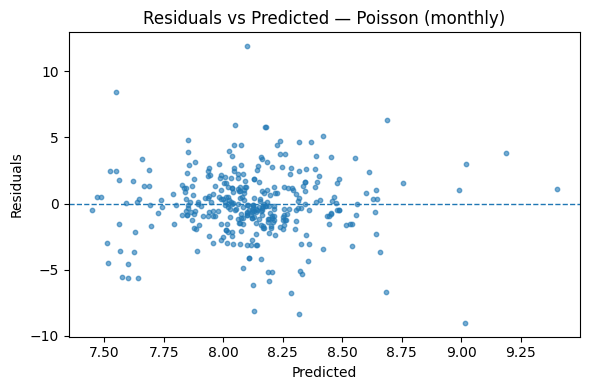

In [22]:
# --- G) Residuals vs Predicted (uses best of Poisson or HGB by RMSE) ---
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

cands = []
try:
    rmse_p = np.sqrt(mean_squared_error(y_test_m, yhat_pois_m))
    cands.append(("Poisson", yhat_pois_m, rmse_p))
except Exception:
    pass
rmse_h = np.sqrt(mean_squared_error(y_test_m, yhat_hgb_m))
cands.append(("HGB", yhat_hgb_m, rmse_h))
best = sorted(cands, key=lambda t: t[2])[0]
name, yhat_best, _ = best

resid = y_test_m - yhat_best
plt.figure(figsize=(6,4))
plt.scatter(yhat_best, resid, s=10, alpha=0.6)
plt.axhline(0, linestyle='--', lw=1)
plt.xlabel('Predicted'); plt.ylabel('Residuals')
plt.title(f'Residuals vs Predicted — {name} (monthly)')
plt.tight_layout(); plt.show()


Class balance (train): [1111  258]
Class balance (test) : [279  61]

[Logistic] ROC-AUC=0.508 | PR-AUC=0.200
Confusion:
 [[141 138]
 [ 32  29]]
              precision    recall  f1-score   support

           0      0.815     0.505     0.624       279
           1      0.174     0.475     0.254        61

    accuracy                          0.500       340
   macro avg      0.494     0.490     0.439       340
weighted avg      0.700     0.500     0.558       340


[HGB (cal)] ROC-AUC=0.569 | PR-AUC=0.217
Confusion:
 [[279   0]
 [ 61   0]]
              precision    recall  f1-score   support

           0      0.821     1.000     0.901       279
           1      0.000     0.000     0.000        61

    accuracy                          0.821       340
   macro avg      0.410     0.500     0.451       340
weighted avg      0.673     0.821     0.740       340



C:\Users\jgbur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jgbur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jgbur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

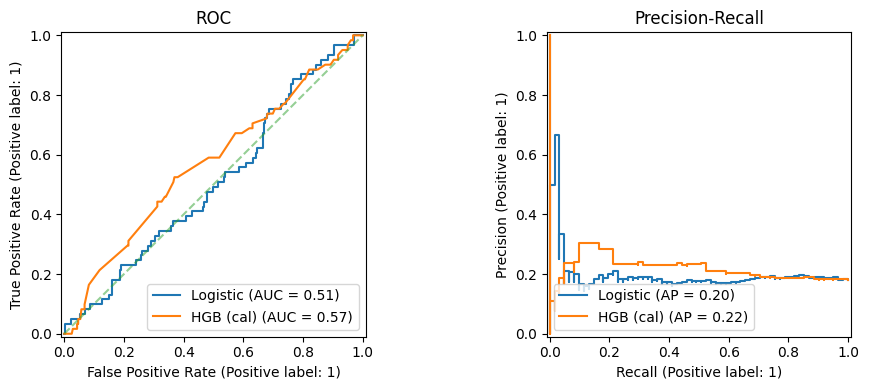

In [23]:
# --- H) High-risk classification: per-city threshold (train-only) + calibration ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay)

# Build classification frame from monthly supervised table
_cols = ['city','date_key','target_next'] + NUMERIC_M + CATEG_M
_cols = list(dict.fromkeys(_cols))  # remove duplicates while preserving order
_cls = _dfmB_sup[_cols].copy()


# Per-city 80th percentile using TRAIN months only
thr80 = (_cls[_cls['date_key'] <= _cutoff_m]
         .groupby('city')['target_next'].quantile(0.80).rename('thr80'))
_cls = _cls.merge(thr80, on='city', how='left')
_cls['is_high_risk'] = (_cls['target_next'] > _cls['thr80']).astype(int)

X_trc = _cls.loc[_cls['date_key'] <= _cutoff_m, NUMERIC_M + CATEG_M]
y_trc = _cls.loc[_cls['date_key'] <= _cutoff_m, 'is_high_risk'].astype(int)
X_tec = _cls.loc[_cls['date_key']  > _cutoff_m, NUMERIC_M + CATEG_M]
y_tec = _cls.loc[_cls['date_key']  > _cutoff_m, 'is_high_risk'].astype(int)
print("Class balance (train):", np.bincount(y_trc))
print("Class balance (test) :", np.bincount(y_tec))

# Logistic baseline
logit_m = Pipeline([
    ('prep', preprocess_linear_m),
    ('mdl', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
logit_m.fit(X_trc, y_trc)
proba_log = logit_m.predict_proba(X_tec)[:,1]
pred_log  = (proba_log >= 0.5).astype(int)

print("\n[Logistic] ROC-AUC={:.3f} | PR-AUC={:.3f}".format(
    roc_auc_score(y_tec, proba_log), average_precision_score(y_tec, proba_log)))
print("Confusion:\n", confusion_matrix(y_tec, pred_log))
print(classification_report(y_tec, pred_log, digits=3))

# Gradient boosting + isotonic calibration
hgb_c = Pipeline([
    ('prep', preprocess_tree_m),
    ('mdl', HistGradientBoostingClassifier(
        learning_rate=0.08, max_depth=None, max_bins=255,
        min_samples_leaf=15, random_state=42))
])
cal_hgb_c = CalibratedClassifierCV(hgb_c, method='isotonic', cv=3)
cal_hgb_c.fit(X_trc, y_trc)
proba_hgb = cal_hgb_c.predict_proba(X_tec)[:,1]
pred_hgb  = (proba_hgb >= 0.5).astype(int)

print("\n[HGB (cal)] ROC-AUC={:.3f} | PR-AUC={:.3f}".format(
    roc_auc_score(y_tec, proba_hgb), average_precision_score(y_tec, proba_hgb)))
print("Confusion:\n", confusion_matrix(y_tec, pred_hgb))
print(classification_report(y_tec, pred_hgb, digits=3))

# Curves
fig, ax = plt.subplots(1,2, figsize=(10,4))
RocCurveDisplay.from_predictions(y_tec, proba_log, ax=ax[0], name='Logistic')
RocCurveDisplay.from_predictions(y_tec, proba_hgb, ax=ax[0], name='HGB (cal)')
ax[0].plot([0,1],[0,1],'--', alpha=0.5); ax[0].set_title("ROC")

PrecisionRecallDisplay.from_predictions(y_tec, proba_log, ax=ax[1], name='Logistic')
PrecisionRecallDisplay.from_predictions(y_tec, proba_hgb, ax=ax[1], name='HGB (cal)')
ax[1].set_title("Precision-Recall")
plt.tight_layout(); plt.show()


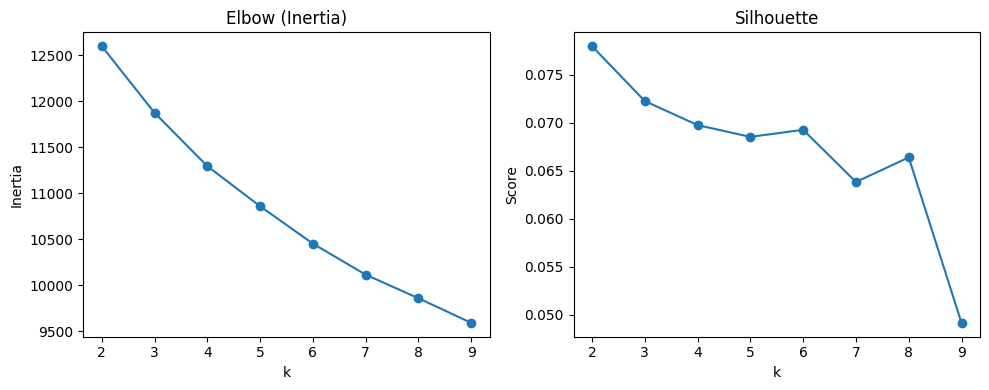

Chosen k: 2
Cluster feature means:


,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_capacity
cluster,,,,,,,,
0,279.00,35.29,48.79,31.71,40.56,14.51,47.98,970.21
1,221.27,35.23,51.64,28.59,39.99,19.61,64.42,1052.99


City composition (top 20 rows):


,cluster,city,count
5,0,Mexico City,118
2,0,Delhi,114
3,0,London,112
0,0,Beijing,110
4,0,Los Angeles,105
7,0,Tokyo,104
1,0,Cairo,75
6,0,São Paulo,61
8,1,Beijing,141
10,1,Delhi,137


In [24]:
# --- I) Unsupervised clustering over monthly features ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt

Xc = _dfmB_sup[['city','date_key'] + NUMERIC_M].dropna().copy()
scaler_c = StandardScaler()
Xz_c = scaler_c.fit_transform(Xc[NUMERIC_M])

ks = range(2, 10)
inert, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    lab = km.fit_predict(Xz_c)
    inert.append(km.inertia_)
    sils.append(silhouette_score(Xz_c, lab))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(list(ks), inert, marker='o'); ax[0].set_title("Elbow (Inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(ks), sils, marker='o'); ax[1].set_title("Silhouette")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = int(ks[int(np.argmax(sils))]) if len(sils) else 3
print("Chosen k:", best_k)

kmeans_c = KMeans(n_clusters=best_k, n_init=50, random_state=42)
labels_c = kmeans_c.fit_predict(Xz_c)

prof_df = Xc.copy()
prof_df['cluster'] = labels_c
cluster_means = prof_df.groupby('cluster')[NUMERIC_M].mean().round(2)
city_mix = (prof_df.groupby(['cluster','city']).size()
            .reset_index(name='count')
            .sort_values(['cluster','count'], ascending=[True,False]))

print("Cluster feature means:")
display(cluster_means)
print("City composition (top 20 rows):")
display(city_mix.head(20))



**Ethics & Limitations**  
This study is **observational**; associations do not imply causation. Respiratory admissions reflect many unobserved factors (e.g., influenza waves, behavior, access to care), so pollutant effects may be confounded. The dataset spans far-future dates, suggesting a **synthetic** component; interpret absolute magnitudes cautiously. To reduce leakage, we used a **time-aware split** and computed high-risk thresholds per city on **training data only**. We calibrated classification probabilities to avoid over-confidence and recommend fairness checks by **city** and **density tier** before operational use.


In [25]:
# --- J) F1-based high-risk month classification (global threshold, feedback-focused) ---
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Build supervised frame from monthly table
_cols = ['city', 'date_key', 'target_next'] + NUMERIC_M + CATEG_M
_cols = list(dict.fromkeys(_cols))  # remove duplicates while preserving order
_cls = _dfmB_sup[_cols].copy()

# Time-aware split based on date_key (80% train, 20% test)
_cls = _cls.sort_values('date_key')
cutoff_date = _cls['date_key'].quantile(0.8)
train_mask = _cls['date_key'] <= cutoff_date
test_mask  = _cls['date_key'] > cutoff_date

X_train_cls = _cls.loc[train_mask, NUMERIC_M + CATEG_M]
y_train_reg = _cls.loc[train_mask, 'target_next'].astype(float)
X_test_cls  = _cls.loc[test_mask,  NUMERIC_M + CATEG_M]
y_test_reg  = _cls.loc[test_mask,  'target_next'].astype(float)

# Define "high" admissions as top 20% of training months
high_thr = y_train_reg.quantile(0.80)
print('High-admissions threshold (train 80th percentile):', high_thr)

y_train = (y_train_reg >= high_thr).astype(int)
y_test  = (y_test_reg  >= high_thr).astype(int)

clf_F1 = Pipeline(steps=[
    ('pre', preprocess_tree_m),
    ('mdl', RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ))
])

clf_F1.fit(X_train_cls, y_train)
proba_test = clf_F1.predict_proba(X_test_cls)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

# Metrics
if y_test.nunique() > 1:
    roc = roc_auc_score(y_test, proba_test)
    pr_auc = average_precision_score(y_test, proba_test)
else:
    roc = np.nan
    pr_auc = np.nan

cm = confusion_matrix(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('=== Overall high-risk month classification (RandomForest) ===')
print('ROC-AUC:', roc)
print('PR-AUC:', pr_auc)
print('F1 (macro):', f1_macro)
print('F1 (weighted):', f1_weighted)
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm)
print('\nClassification report (per class):')
print(classification_report(y_test, y_pred, digits=3))

High-admissions threshold (train 80th percentile): 9.8
=== Overall high-risk month classification (RandomForest) ===
ROC-AUC: 0.5981988585789831
PR-AUC: 0.3030220330664467
F1 (macro): 0.45632309941520466
F1 (weighted): 0.7058877278981768
Confusion matrix [[TN, FP], [FN, TP]]:
[[269   0]
 [ 70   1]]

Classification report (per class):
              precision    recall  f1-score   support

           0      0.794     1.000     0.885       269
           1      1.000     0.014     0.028        71

    accuracy                          0.794       340
   macro avg      0.897     0.507     0.456       340
weighted avg      0.837     0.794     0.706       340



In [26]:
# --- K) City-level F1 scores for high-risk classification ---
test_cities = _cls.loc[test_mask, 'city'].values

rows = []
for city_name in np.unique(test_cities):
    m = (test_cities == city_name)
    if len(np.unique(y_test[m])) < 2:
        city_f1 = np.nan
    else:
        city_f1 = f1_score(y_test[m], y_pred[m])
    rows.append({'city': city_name, 'F1': city_f1})

city_f1_df = (
    pd.DataFrame(rows)
      .sort_values('F1', ascending=False)
      .reset_index(drop=True)
)

print('City-level F1 scores (how well high-risk months are identified per city):')
display(city_f1_df)

City-level F1 scores (how well high-risk months are identified per city):


,city,F1
0,Cairo,0.111111
1,Beijing,0.000000
2,Delhi,0.000000
3,London,0.000000
4,Los Angeles,0.000000
5,Mexico City,0.000000
6,São Paulo,0.000000
7,Tokyo,0.000000


In [27]:
# --- L) City pollution / capacity / admissions profile (for cross-city comparison) ---
city_profile = (
    df.groupby('city')
      .agg({
          'aqi':'mean',
          'pm2_5':'mean',
          'pm10':'mean',
          'no2':'mean',
          'o3':'mean',
          'temperature':'mean',
          'humidity':'mean',
          'hospital_capacity':'mean',
          'hospital_admissions':'mean',
      })
      .round(2)
      .reset_index()
)

print(f'Average pollution, capacity, and admissions per city (years <= {MAX_YEAR}):')
display(city_profile)

Average pollution, capacity, and admissions per city (years <= 2040):


,city,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_capacity,hospital_admissions
0,Beijing,254.15,35.09,50.49,29.82,39.87,17.65,57.05,1010.41,8.17
1,Cairo,259.74,36.71,50.20,31.01,40.81,17.03,57.63,1052.16,8.51
2,Delhi,250.28,34.77,50.09,30.05,40.14,17.01,56.95,1005.43,8.06
3,London,247.33,35.91,49.07,29.69,40.59,17.36,57.58,1034.12,8.18
4,Los Angeles,250.66,35.15,50.61,29.39,39.37,17.96,57.01,1020.57,7.95
5,Mexico City,244.63,35.58,50.06,29.14,40.31,17.36,55.74,1011.29,8.08
6,São Paulo,228.15,34.01,50.99,31.45,41.18,16.62,54.49,994.62,7.85
7,Tokyo,251.16,35.25,50.43,30.45,39.37,17.38,56.58,1043.11,8.03
